# Minimum Lens System Search — Progressive Constraint Tightening

**Problem**: Find the minimum number of lenses to focus a circular Gaussian beam to a target waist.

| Parameter | Value |
|-----------|-------|
| Wavelength λ | 1.064 µm |
| Input waist w₀ | 2.0 mm |
| Target position z | 200 mm |
| Target waist w | 0.1 mm |
| Waist tolerance Δz | ±10 mm |

**Strategy**: Start with minimal constraints to find the theoretical minimum,
then progressively tighten towards a realistic, manufacturable lens system.

| Step | Added constraint | Physical meaning |
|------|-----------------|------------------|
| 1 | f ∈ (−10000, 10000) mm, no sep. | Theoretical baseline |
| 2 | Lens separation ≥ 20 mm | Mechanical clearance |
| 3 | \|f\| ∈ [30, 1000] mm | Standard catalog lenses |

In [1]:
%matplotlib inline
import numpy as np
import matplotlib.pyplot as plt

from gbeampro import GaussBeam, OpticalSystem, Propagation
from gbeampro.optimize import waist_operands, find_minimum_system, build_xy_systems
import gbeampro.plot as gplot
import gbeampro.analysis as ga
import gbeampro
print('gbeampro version:', gbeampro.__version__)

gbeampro version: 2.0.0


## Problem Setup

In [2]:
WL        = 1.064   # µm
W0        = 2.0     # mm
Z_TARGET  = 200.0   # mm
W_TARGET  = 0.1     # mm
WAIST_TOL = 10.0    # mm

beam = GaussBeam.from_waist(wl_um=WL, w0_mm=W0)
print(beam)

z_R = np.pi * W0**2 / (WL * 1e-3)
print(f'\nRayleigh range:       z_R = {z_R:.0f} mm')
print(f'Beam size at z=200mm: w   = {beam.w_mm * np.sqrt(1+(Z_TARGET/z_R)**2)*1e3:.2f} µm  (no optics)')
print(f'Target:               w   = {W_TARGET*1e3:.0f} µm')

operands = waist_operands(
    z_mm=Z_TARGET, wx_mm=W_TARGET, wy_mm=W_TARGET,
    size_weight=1.0,
    waist_tol_x_mm=WAIST_TOL,
    waist_tol_y_mm=WAIST_TOL,
)
print(f'\nMerit function operands:')
for op in operands:
    print(f'  {op.type:<4}  target={op.target:.4g}  weight={op.weight:.3g}')

GaussBeam(wl_um=1.064, n=1.0, z_mm=0.00000, R_mm=inf, w_mm=2.00000)
  q = 0.00000e+00-1.18105e+04j  theta = 0.1693 mrad

Rayleigh range:       z_R = 11810 mm
Beam size at z=200mm: w   = 2000.29 µm  (no optics)
Target:               w   = 100 µm

Merit function operands:
  wx    target=0.1  weight=1
  wy    target=0.1  weight=1
  cvx   target=0  weight=4
  cvy   target=0  weight=4


## Helper functions

In [3]:
def print_specs(result):
    print(f"{'#':>2}  {'z (mm)':>10}  {'f (mm)':>10}  {'|f| (mm)':>10}")
    print('   ' + '-' * 36)
    for i, s in enumerate(result.specs, 1):
        ftype = 'conv.' if s['f_mm'] > 0 else 'div.'
        print(f"{i:>2}  {s['z_mm']:>10.2f}  {s['f_mm']:>10.2f}  {abs(s['f_mm']):>10.2f}  ({ftype})")
    if len(result.specs) > 1:
        seps = [result.specs[i+1]['z_mm'] - result.specs[i]['z_mm']
                for i in range(len(result.specs)-1)]
        print(f'  separations: {[f"{d:.1f} mm" for d in seps]}')

def plot_result(result, n, title, z_end=Z_TARGET+50):
    sx, _ = build_xy_systems(beam, result.specs, z_end)
    traj = sx.trace(beam, dz=0.5)
    waists = ga.find_waists(traj)
    fig, ax = plt.subplots(figsize=(11, 3.5))
    gplot.plot_system(sx, traj, ax, label='beam')
    ax.axvline(Z_TARGET, color='k', ls=':', lw=1.2, label=f'z={Z_TARGET:.0f} mm')
    ax.scatter([Z_TARGET], [W_TARGET*1e3], color='r', zorder=6, s=80, label='target')
    ax.set_title(title)
    plt.tight_layout()
    print('Waists found:')
    for w in waists:
        dz = w.z_mm - Z_TARGET
        dw = (w.w_mm - W_TARGET) / W_TARGET * 100
        print(f'  z={w.z_mm:.1f} mm (Δz={dz:+.1f})  '
              f'w₀={w.w_mm*1e3:.2f} µm ({dw:+.1f}%)  '
              f'2z_R={2*ga.rayleigh_range(w):.1f} mm')
    return sx, traj

## Step 1: Theoretical Baseline

No mechanical constraints — lenses can be arbitrarily close
and any focal length is allowed.
This gives the **theoretical minimum** number of lenses.

In [4]:
r1, n1 = find_minimum_system(
    beam, operands,
    lens_type='spherical',
    max_lenses=5,
    merit_threshold=1e-3,
    f_bounds=(-10000, 10000),
    min_lens_sep_mm=0.0,
    algorithm='de',
    verbose=True,
)
print(f'\n→ Minimum: {n1} lens(es),  merit = {r1.merit:.2e}')
print_specs(r1)

n=1  merit=9.335e+01  operands=[0.6038, 0.6038, -0.01154, -0.01154]


n=2  merit=1.094e-28  operands=[0.1, 0.1, 1.528e-17, 1.528e-17]

→ Minimum: 2 lens(es),  merit = 1.09e-28
 #      z (mm)      f (mm)    |f| (mm)
   ------------------------------------
 1        8.26      187.28      187.28  (conv.)
 2      185.49      -12.74       12.74  (div.)
  separations: ['177.2 mm']


Waists found:
  z=200.5 mm (Δz=+0.5)  w₀=100.01 µm (+0.0%)  2z_R=59.1 mm


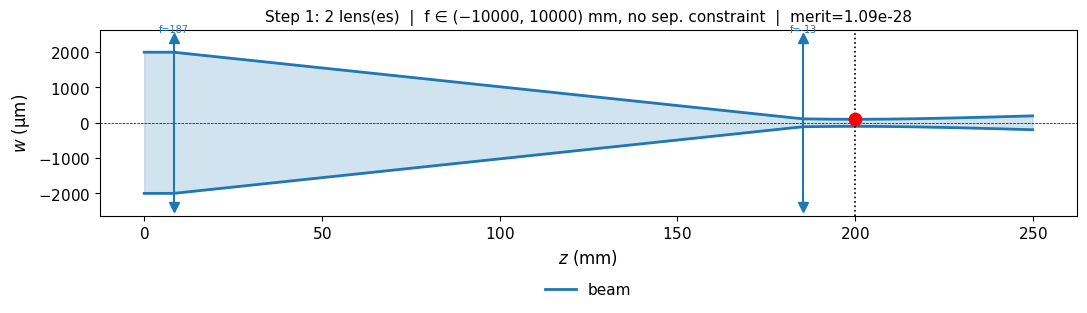

In [5]:
sx1, traj1 = plot_result(r1, n1,
    f'Step 1: {n1} lens(es)  |  f ∈ (−10000, 10000) mm, no sep. constraint  |  merit={r1.merit:.2e}')

## Step 2: Add Mechanical Separation Constraint

Adjacent lenses must be at least **20 mm apart**
(mechanical clearance for mounts and holders).

In [6]:
r2, n2 = find_minimum_system(
    beam, operands,
    lens_type='spherical',
    max_lenses=5,
    merit_threshold=1e-3,
    f_bounds=(-10000, 10000),
    min_lens_sep_mm=20.0,
    algorithm='de',
    verbose=True,
)
print(f'\n→ Minimum: {n2} lens(es),  merit = {r2.merit:.2e}')
print_specs(r2)

n=1  merit=9.335e+01  operands=[0.6038, 0.6038, -0.01154, -0.01154]


n=2  merit=7.414e-14  operands=[0.1, 0.1, 4.103e-10, 4.103e-10]

→ Minimum: 2 lens(es),  merit = 7.41e-14
 #      z (mm)      f (mm)    |f| (mm)
   ------------------------------------
 1        2.54      197.60      197.60  (conv.)
 2      190.22      -12.35       12.35  (div.)
  separations: ['187.7 mm']


Waists found:
  z=200.2 mm (Δz=+0.2)  w₀=100.00 µm (+0.0%)  2z_R=59.1 mm


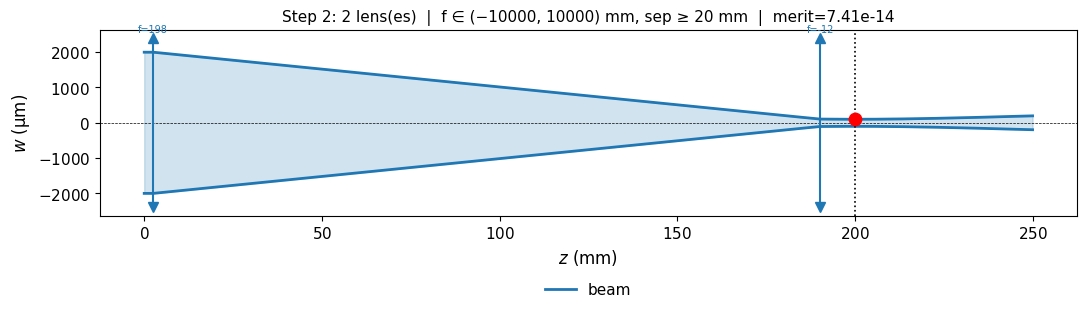

In [7]:
sx2, traj2 = plot_result(r2, n2,
    f'Step 2: {n2} lens(es)  |  f ∈ (−10000, 10000) mm, sep ≥ 20 mm  |  merit={r2.merit:.2e}')

## Step 3: Add Focal Length Constraint

Restrict to **|f| ∈ [30, 1000] mm** — representative of standard catalog lenses.
Both converging (f > 0) and diverging (f < 0) lenses are allowed.

In [8]:
r3, n3 = find_minimum_system(
    beam, operands,
    lens_type='spherical',
    max_lenses=5,
    merit_threshold=1e-3,
    f_abs_bounds=(30, 1000),
    min_lens_sep_mm=20.0,
    algorithm='de',
    verbose=True,
)
print(f'\n→ Minimum: {n3} lens(es),  merit = {r3.merit:.2e}')
print_specs(r3)

n=1  merit=9.335e+01  operands=[0.6038, 0.6038, -0.01154, -0.01154]


n=2  merit=4.893e+00  operands=[0.2543, 0.2543, -0.0006408, -0.0006408]


n=3  merit=6.649e-17  operands=[0.1, 0.1, -1.434e-11, -1.434e-11]

→ Minimum: 3 lens(es),  merit = 6.65e-17
 #      z (mm)      f (mm)    |f| (mm)
   ------------------------------------
 1        9.41      132.40      132.40  (conv.)
 2      113.98      -39.90       39.90  (div.)
 3      185.78      -55.85       55.85  (div.)
  separations: ['104.6 mm', '71.8 mm']


Waists found:
  z=200.3 mm (Δz=+0.3)  w₀=100.01 µm (+0.0%)  2z_R=59.1 mm


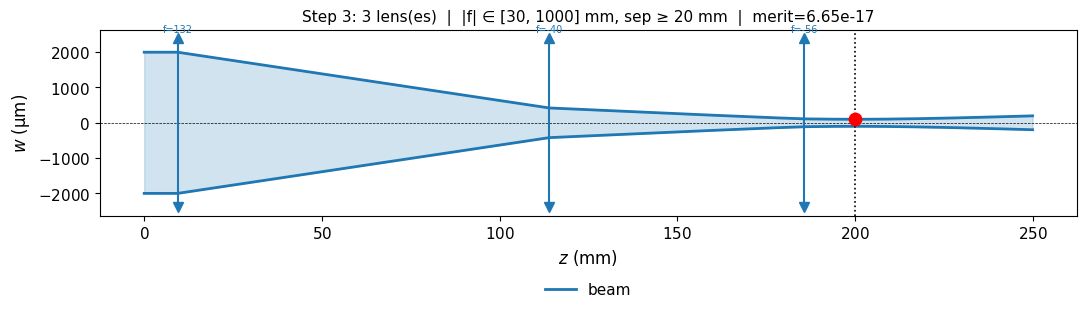

In [9]:
sx3, traj3 = plot_result(r3, n3,
    f'Step 3: {n3} lens(es)  |  |f| ∈ [30, 1000] mm, sep ≥ 20 mm  |  merit={r3.merit:.2e}')

## Summary

In [10]:
print(f"{'Step':<6}  {'Constraint':<42}  {'N':>4}  {'merit':>10}")
print('-' * 68)
for step, desc, n, res in [
    ('1', 'f ∈ (−10000, 10000), no sep.',       n1, r1),
    ('2', 'f ∈ (−10000, 10000), sep ≥ 20 mm',  n2, r2),
    ('3', '|f| ∈ [30, 1000] mm, sep ≥ 20 mm',  n3, r3),
]:
    print(f'{step:<6}  {desc:<42}  {n:>4}  {res.merit:>10.2e}')

print()
print('Step 3 (most realistic) system:')
print(sx3.summary(beam))

Step    Constraint                                     N       merit
--------------------------------------------------------------------
1       f ∈ (−10000, 10000), no sep.                   2    1.09e-28
2       f ∈ (−10000, 10000), sep ≥ 20 mm               2    7.41e-14
3       |f| ∈ [30, 1000] mm, sep ≥ 20 mm               3    6.65e-17

Step 3 (most realistic) system:


OpticalSystem trace  [wl=1.064 um]
   #  Type                   z (mm)     w (um)      R (mm)   th (urad)
------------------------------------------------------------------------
   0  --- input ---           0.000    2000.00         inf      169.34
   1  Propagation             9.411    2000.00   1.482e+07      169.34
   2  ThinLens                9.411    2000.00  -1.324e+02      169.34
   3  Propagation           113.981     420.75  -2.789e+01      804.95
   4  ThinLens              113.981     420.75  -9.267e+01      804.95
   5  Propagation           185.776     111.00  -3.210e+01     3051.22
   6  ThinLens              185.776     111.00  -7.552e+01     3051.22
   7  Propagation           250.000     196.66   6.744e+01     1722.14
Beam waists:  z=200.007 mm (2w0=200.0 um)


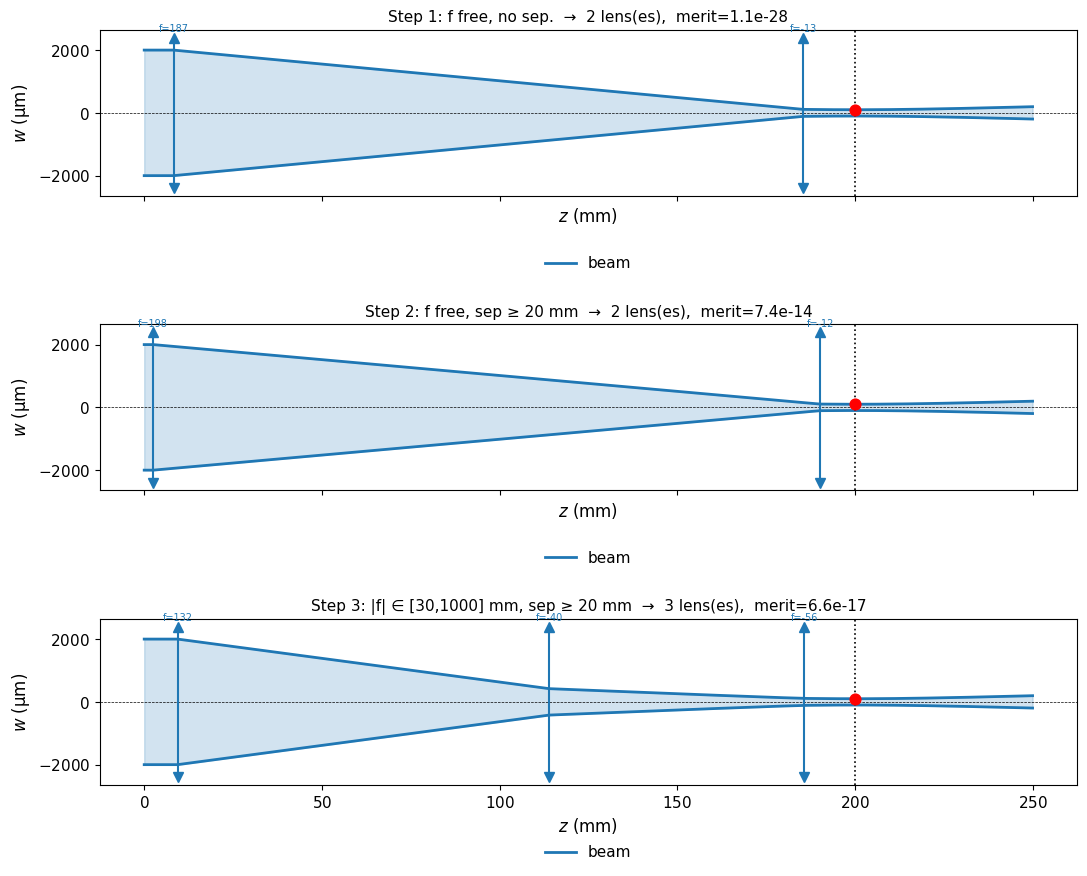

In [11]:
Z_END = Z_TARGET + 50
fig, axes = plt.subplots(3, 1, figsize=(11, 9), sharex=True)

for ax, (res, n, label) in zip(axes, [
    (r1, n1, 'Step 1: f free, no sep.'),
    (r2, n2, 'Step 2: f free, sep ≥ 20 mm'),
    (r3, n3, 'Step 3: |f| ∈ [30,1000] mm, sep ≥ 20 mm'),
]):
    sx, _ = build_xy_systems(beam, res.specs, Z_END)
    traj = sx.trace(beam, dz=0.5)
    gplot.plot_system(sx, traj, ax, label='beam')
    ax.axvline(Z_TARGET, color='k', ls=':', lw=1.2)
    ax.scatter([Z_TARGET], [W_TARGET*1e3], color='r', zorder=6, s=60, label='target')
    ax.set_title(f'{label}  →  {n} lens(es),  merit={res.merit:.1e}')

plt.tight_layout()